# Classificação pelo centroide mais próximo

**Autor:** Prof. Dr. Sergio Antônio Andrade de Freitas  
**Material da disciplina:** FGA0083 — Aprendizado de Máquina, UnB

## Objetivo e dados

Visualizar protótipos e regiões de decisão.

**Pergunta-guia:** Quais classes se confundem e por que a distância ao centroide pode falhar?

Execute as células na ordem e interprete os resultados antes de fazer o exercício.

Relatório de Classificação:
               precision    recall  f1-score   support

           0       0.71      0.56      0.62         9
           1       1.00      0.75      0.86        16
           2       0.71      1.00      0.83        15

    accuracy                           0.80        40
   macro avg       0.81      0.77      0.77        40
weighted avg       0.83      0.80      0.80        40

Matriz de Confusão:
 [[ 5  0  4]
 [ 2 12  2]
 [ 0  0 15]]


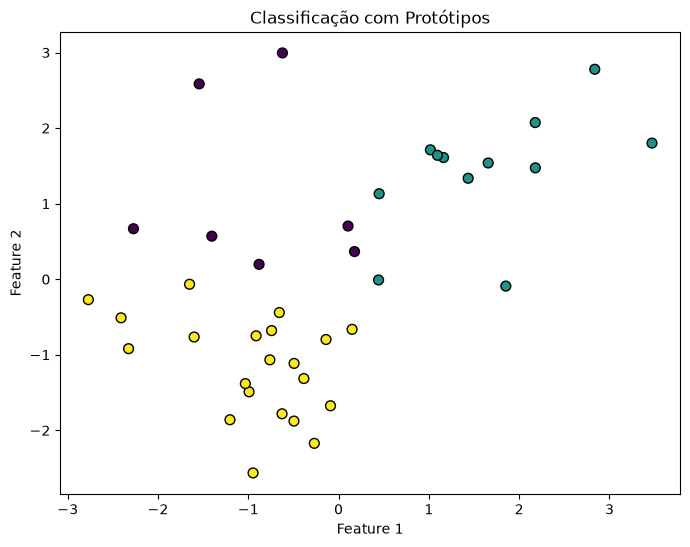

In [1]:
# Ajustando os parâmetros para a criação do conjunto de dados e re-executando o exemplo prático

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.neighbors import NearestCentroid
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

# Gerar um conjunto de dados sintético com configurações ajustadas
X, y = make_classification(n_samples=200, n_features=2, n_informative=2, n_redundant=0, n_clusters_per_class=1, n_classes=3, random_state=42)

# Dividir os dados em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Criar e treinar o modelo NearestCentroid
modelo_prototipos = NearestCentroid()
modelo_prototipos.fit(X_train, y_train)

# Realizar previsões no conjunto de teste
y_pred = modelo_prototipos.predict(X_test)

# Avaliar o modelo
relatorio = classification_report(y_test, y_pred)
matriz = confusion_matrix(y_test, y_pred)

# Exibir resultados
print("Relatório de Classificação:\n", relatorio)
print("Matriz de Confusão:\n", matriz)

# Visualizar os resultados
plt.figure(figsize=(8, 6))
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_pred, cmap='viridis', edgecolor='black', s=50)
plt.title('Classificação com Protótipos')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

## Investigação complementar

Compare a nova medida com a figura ou o resultado anterior. Explique qualquer diferença observada.

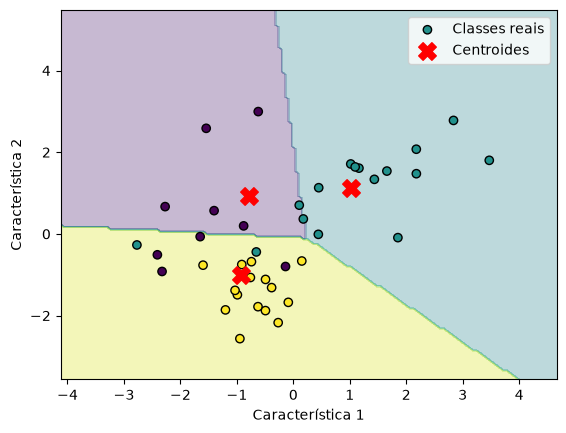

Acurácia centroide: 0.8
Acurácia KNN: 0.825


In [2]:
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
xx, yy = np.meshgrid(np.linspace(X[:,0].min()-1, X[:,0].max()+1, 150),
                     np.linspace(X[:,1].min()-1, X[:,1].max()+1, 150))
grade = np.c_[xx.ravel(), yy.ravel()]
plt.contourf(xx, yy, modelo_prototipos.predict(grade).reshape(xx.shape), alpha=0.3)
plt.scatter(X_test[:,0], X_test[:,1], c=y_test, edgecolor='k', label='Classes reais')
plt.scatter(*modelo_prototipos.centroids_.T, marker='X', s=160, c='red', label='Centroides')
plt.legend(); plt.xlabel('Característica 1'); plt.ylabel('Característica 2'); plt.show()
vizinho = KNeighborsClassifier(n_neighbors=3).fit(X_train, y_train)
print('Acurácia centroide:', modelo_prototipos.score(X_test, y_test))
print('Acurácia KNN:', vizinho.score(X_test, y_test))

## Interpretação e limites

Um centroide por classe não representa classes multimodais.

## Exercício

Compare KNN nos mesmos dados e explore `data/10.1 - dados_classificacao_prototipos.csv`.

Registre a hipótese, a mudança realizada, a métrica ou figura observada e uma conclusão que os dados de fato sustentem.